In [3]:
import pandas as pd
import soundfile as sf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def plot_audio_length_vs_metricf(base_folder, species, audio_format="flac", plot_column="energy_consumed"):
    # Initialize lists to store data
    audio_lengths = []
    metric_values = []
    compression_levels = []
    aggregated_data = {}

    # Define valid species folders
    species_folders = ["Thyolo", "Gibbon", "PTW"]
    
    if species not in species_folders:
        print(f"Unsupported species: {species}. Choose from {species_folders}")
        return

    # Define the folder paths for each audio format
    folder_paths = {
        "flac": "flac",
        "aac": "aac",
        "mp3": "mp3",
        "ogg": "ogg"
    }

    if audio_format.lower() not in folder_paths:
        print(f"Unsupported format: {audio_format}. Supported formats: flac, aac, mp3, ogg.")
        return

    # Construct the correct folder path
    audio_folder_path = Path(base_folder) / species / "Compressed_Audio" / folder_paths[audio_format.lower()]
    
    if not audio_folder_path.exists():
        print(f"Folder for {species} - {audio_format.upper()} does not exist: {audio_folder_path}")
        return

    # Define file extensions
    format_extensions = {
        "flac": "*.flac",
        "aac": "*.aac",
        "mp3": "*.mp3",
        "ogg": "*.ogg"
    }

    audio_extension = format_extensions[audio_format.lower()]

    # Find the first CSV to display column options
    found_csv = None
    for audio_file in audio_folder_path.rglob(audio_extension):
        csv_file = audio_file.parent / f"emissions_output_{audio_file.stem}.csv"
        if csv_file.exists():
            found_csv = csv_file
            break  # Stop after finding the first CSV

    if found_csv:
        try:
            df = pd.read_csv(found_csv)
            print("\nAvailable columns in CSV:")
            print(df.columns.tolist())  # Print all available columns
            print("\n")
        except Exception as e:
            print(f"Error reading {found_csv}: {e}")
            return
    else:
        print(f"No CSV files found in {audio_folder_path}. Cannot display column options.")
        return

    # Proceed with normal processing
    for audio_file in audio_folder_path.rglob(audio_extension):  
        print(f"Processing {species} {audio_format.upper()} file: {audio_file}")

        csv_file = audio_file.parent / f"emissions_output_{audio_file.stem}.csv"

        if csv_file.exists():
            try:
                # Load audio file
                audio_data, sample_rate = sf.read(audio_file)
                audio_length = len(audio_data) / sample_rate
                audio_lengths.append(audio_length)

                # Extract compression level
                compression_level_str = audio_file.stem.split(f"_{audio_format}_")[-1]
                compression_level = int(compression_level_str)
                compression_levels.append(compression_level)

                # Load CSV for selected metric
                df = pd.read_csv(csv_file)

                # Check if the selected column exists
                if plot_column not in df.columns:
                    print(f"Column '{plot_column}' not found in {csv_file}. Available columns: {df.columns.tolist()}")
                    return
                
                metric_value = df[plot_column].iloc[0]  # Extract first value
                metric_values.append(metric_value)

                # Aggregate data
                if compression_level not in aggregated_data:
                    aggregated_data[compression_level] = {'total_length': 0, 'total_metric': 0}

                aggregated_data[compression_level]['total_length'] += audio_length
                aggregated_data[compression_level]['total_metric'] += metric_value * audio_length

            except Exception as e:
                print(f"Error processing {audio_file.name} or {csv_file.name}: {e}")
        else:
            print(f"CSV not found for {audio_file.name}")

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        'Audio Length (seconds)': audio_lengths,
        f'{plot_column}': metric_values,
        'Compression Level': compression_levels
    })

    # Set Seaborn style
    sns.set(style="whitegrid")

    # Sort compression levels
    unique_compression_levels = sorted(plot_data['Compression Level'].unique())
    num_levels = len(unique_compression_levels)
    fig, axes = plt.subplots(1, num_levels, figsize=(15, 6), sharey=True)

    if num_levels == 1:
        axes = [axes]

    for i, level in enumerate(unique_compression_levels):
        ax = axes[i]
        data_level = plot_data[plot_data['Compression Level'] == level]
        sns.scatterplot(x='Audio Length (seconds)', y=plot_column, data=data_level, ax=ax, s=100, alpha=0.7, edgecolor='w')

        metric_in_joules = data_level[plot_column] * data_level['Audio Length (seconds)']
        metric_to_length_ratio = (metric_in_joules / data_level['Audio Length (seconds)']).mean()

        ax.set_title(f'{species} - Compression {level}', fontsize=14)
        ax.set_xlabel('Audio Length (seconds)', fontsize=12)
        ax.set_ylabel(plot_column, fontsize=12)

        ax.text(0.5, -0.1, f'{plot_column}/Length Ratio: {metric_to_length_ratio:.4f}', 
                ha='center', va='top', transform=ax.transAxes, fontsize=12)

    print("\nAggregated Results per Compression Level:")
    for level, data in aggregated_data.items():
        total_length = data['total_length']
        total_metric = data['total_metric']
        metric_to_length_ratio_aggregated = total_metric / total_length if total_length > 0 else 0
        print(f"Compression Level {level}:")
        print(f"  - Total Audio Length: {total_length:.2f} seconds")
        print(f"  - Total {plot_column}: {total_metric:.2f}")
        print(f"  - {plot_column}/Length Ratio: {metric_to_length_ratio_aggregated:.4f}")
        print()

    plt.tight_layout()
    plt.show()


Available columns in CSV:
['timestamp', 'project_name', 'run_id', 'experiment_id', 'duration', 'emissions', 'emissions_rate', 'cpu_power', 'gpu_power', 'ram_power', 'cpu_energy', 'gpu_energy', 'ram_energy', 'energy_consumed', 'country_name', 'country_iso_code', 'region', 'cloud_provider', 'cloud_region', 'os', 'python_version', 'codecarbon_version', 'cpu_count', 'cpu_model', 'gpu_count', 'gpu_model', 'longitude', 'latitude', 'ram_total_size', 'tracking_mode', 'on_cloud', 'pue']


Processing Gibbon MP3 file: E:\Bioacoustics_compressed_sensing\Gibbon\Compressed_Audio\mp3\HGSM3AB_0+1_20160303_060100_mp3_192.mp3
CSV not found for HGSM3AB_0+1_20160303_060100_mp3_192.mp3
Processing Gibbon MP3 file: E:\Bioacoustics_compressed_sensing\Gibbon\Compressed_Audio\mp3\HGSM3AB_0+1_20160303_060100_mp3_320.mp3
CSV not found for HGSM3AB_0+1_20160303_060100_mp3_320.mp3
Processing Gibbon MP3 file: E:\Bioacoustics_compressed_sensing\Gibbon\Compressed_Audio\mp3\HGSM3AB_0+1_20160303_060100_mp3_96.mp3
CSV no

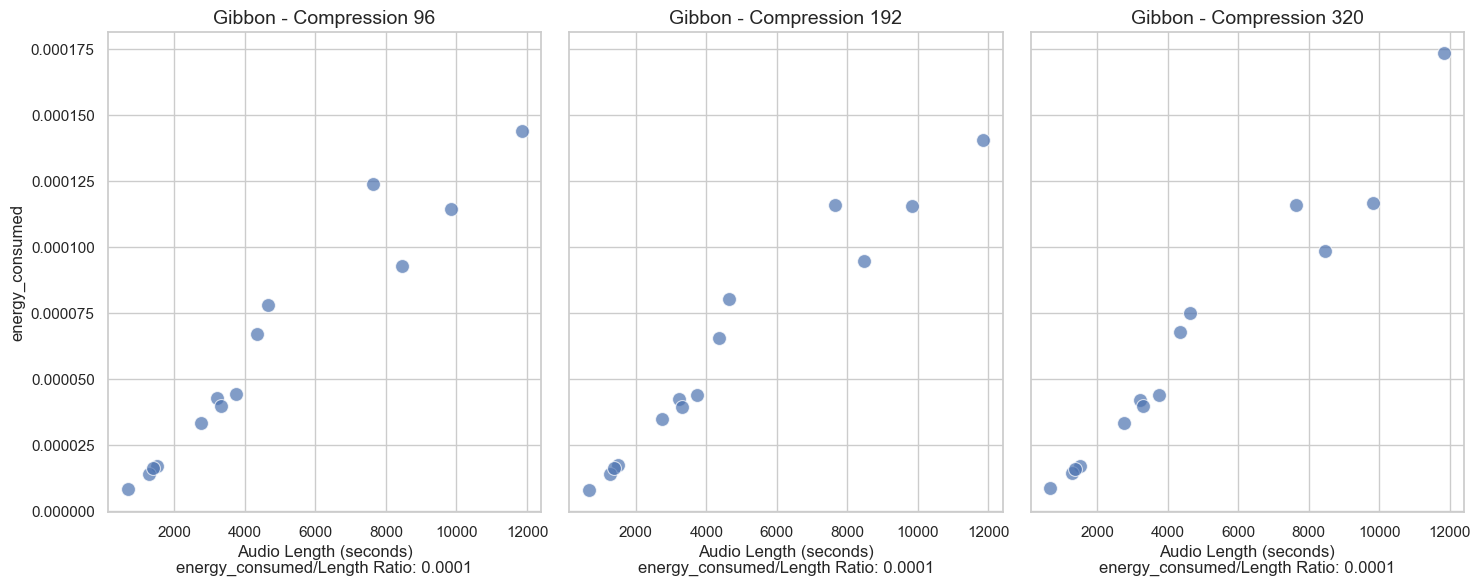

In [4]:
# Define base folder path
base_folder = r"E:/Bioacoustics_compressed_sensing"

# Choose species folder: "Thyolo", "Gibbon", or "PTW"
species = "Gibbon"  

# Choose audio format: "flac", "aac", "mp3", or "ogg"
audio_format = "mp3"  

# Select column to plot (pick from the printed list)
plot_column = "energy_consumed"  # Change this to any valid column

# Call function
plot_audio_length_vs_metricf(base_folder, species, audio_format, plot_column)